In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.metrics import mean_squared_error as MSE
from scipy.stats import gaussian_kde

In [2]:
# Load the dataset
Cars_df = pd.read_csv('Cars.csv')

In [3]:
# Drop rows with any missing values
data_frame = Cars_df.dropna()

In [4]:
data_frame = pd.read_csv('Cars.csv')

# Applying log transformation to the 'Price' column to reduce skewness
data_frame['Log_Price'] = np.log1p(data_frame['Price'])  # log1p is used to handle zero values in the data

filtered_file_path = 'Cars_Filtered.csv'
data_frame.to_csv(filtered_file_path, index=False)

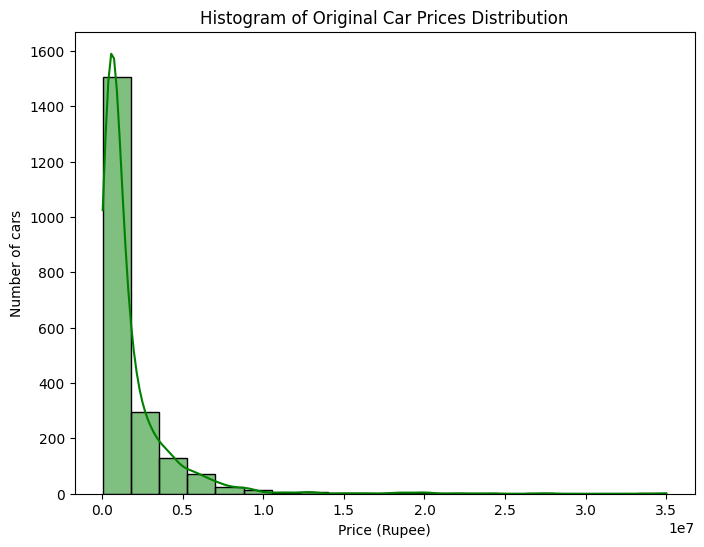

Text(0, 0.5, 'Number of cars')

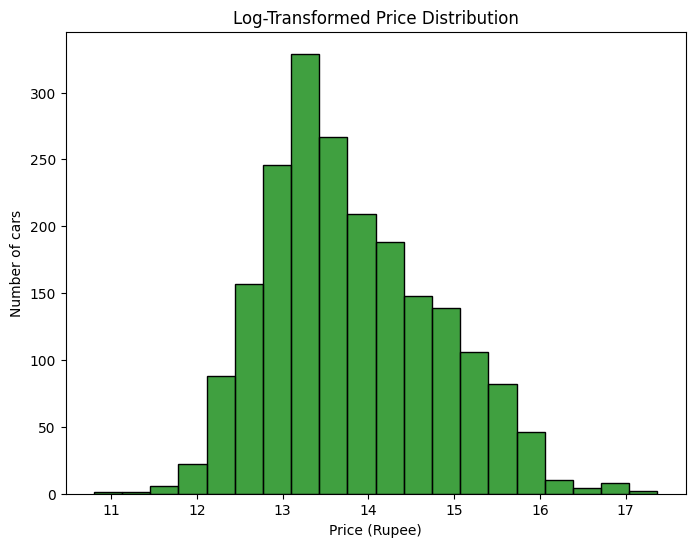

In [5]:
# Plotting the distribution of the original 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Price'], bins=20,kde=True , color="green")
plt.title('Histogram of Original Car Prices Distribution')
plt.xlabel('Price (Rupee)')
plt.ylabel('Number of cars')
plt.show()

# Plotting the distribution of the log-transformed 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Log_Price'], bins=20,color="green")
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Price (Rupee)')
plt.ylabel('Number of cars')
#plt.show()

In [6]:
label_encoder = LabelEncoder()

In [7]:
data_frame['Transmission ID'] = label_encoder.fit_transform(data_frame['Transmission'])
Transmission = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [8]:
# Use a regular expression to remove the non-numeric part
data_frame['Power'] = data_frame['Max Power'].str.replace(r' bhp @ \d+ rpm', '', regex=True)
# Convert the column to a numeric type
data_frame['Power'] = pd.to_numeric(data_frame['Power'], errors='coerce')

In [9]:
# Identify columns that have data type 'object' (text)
text_columns = data_frame.select_dtypes(include=['object']).columns
# Drop the identified text columns
data_frame = data_frame.drop(text_columns, axis=1)
data_frame = data_frame.dropna()
data_frame.to_csv('Cars_Encoded.csv', index=False)

In [10]:
Aim_Price = data_frame["Log_Price"]
data_frame = data_frame.drop(["Log_Price"],axis=1)
data_frame["Aim_Price"]= Aim_Price
data_frame.to_csv("Cars_Final.csv")

In [11]:
data_frame = data_frame[['Year','Seating Capacity','Transmission ID','Power','Aim_Price']]

In [12]:
X = data_frame[['Year','Seating Capacity', 'Transmission ID','Power']]

In [13]:
y = data_frame['Aim_Price']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

Creating the Dxmatrix which are objects from the training and testing sets.
XGBoost's API expects data in this format.

In [15]:
train_dmatrix = xgb.DMatrix(data = X_train, label = y_train)
test_dmatrix = xgb.DMatrix(data = X_test, label = y_test)

The param dictionary defines the model's parameters. In this case, "booster":"gblinear" specifies the booster type to be linear, which means the model will use linear functions for learning. The "objective":"reg:linear" parameter indicates that the model's objective is linear regression

In [16]:
param = {"booster":"gblinear", "objective":"reg:squarederror"}

Training and Testing as usual

In [17]:
xgb_r = xgb.train(params = param, dtrain = train_dmatrix, num_boost_round = 10)
pred = xgb_r.predict(test_dmatrix )

Error rates

In [18]:
rmse = np.sqrt(MSE(y_test, pred))
print("RMSE : % f" %(rmse))

RMSE :  0.494643


In [19]:
mse = MSE(y_test, pred)
print("MSE : % f" %(mse))

MSE :  0.244672


In [20]:
r2 = r2_score(y_test, pred)
print("R² score:", r2)

R² score: 0.6993536540678102


Tuning

In [21]:
# Define the parameter grid
param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

In [22]:
# Initialize the XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror')

In [23]:
# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2)

In [24]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.3s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.4s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; tot

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'colsample_bytree': [0.5, 0.7, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.5, 0.7, 1.0]},
             scoring='neg_mean_squared_error', verbose=2)

In [25]:
# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best parameters found:  {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7}
Best score:  -0.06340296886702333


In [26]:
# Use the best estimator to make predictions
predictions = grid_search.best_estimator_.predict(X_test)

In [27]:
rmse = np.sqrt(MSE(y_test, predictions))
print("RMSE : % f" %(rmse))

RMSE :  0.233740


In [28]:
mse = MSE(y_test, predictions)
print("MSE : % f" %(mse))

MSE :  0.054634


In [29]:
r2 = r2_score(y_test, predictions)
print("R² score:", r2)

R² score: 0.9328667170733442


Visual Information

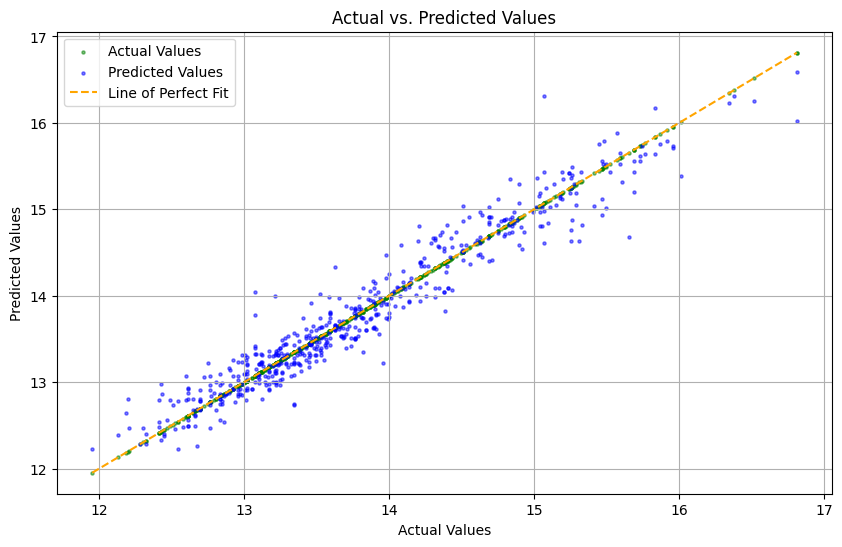

In [30]:
plt.figure(figsize=(10, 6))

# Plot the actual values in green, with smaller circles
plt.scatter(y_test, y_test, color='green', s=5, alpha=0.5, label='Actual Values')  # s is the size of the marker

# Plot the predicted values in blue, with smaller circles
plt.scatter(y_test, predictions, color='blue', s=5, alpha=0.5, label='Predicted Values')  # Same size reduction as actual

# Add an orange line for perfect predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='orange', linestyle='--', label='Line of Perfect Fit')

plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()  # Add a legend to clarify the plot elements
plt.show()


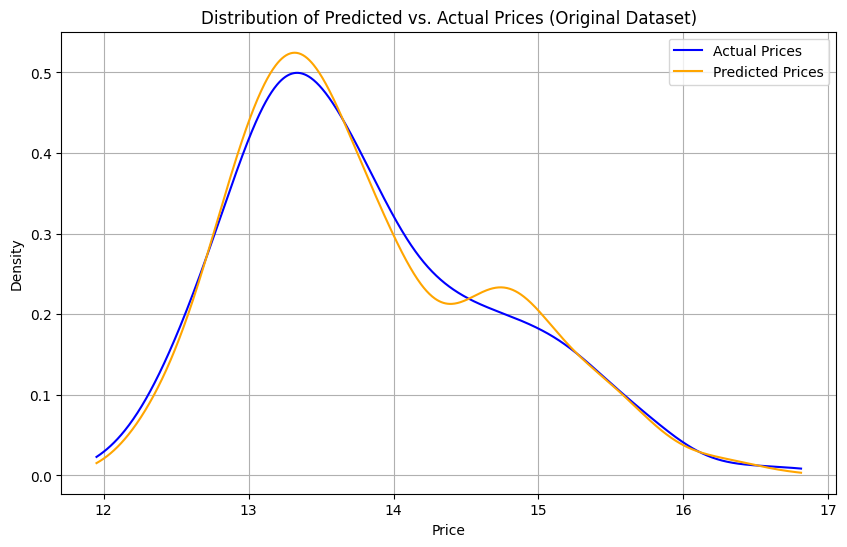

In [32]:
# Set up the figure and axis
plt.figure(figsize=(10, 6))

# Calculate the density using Gaussian Kernel Density Estimation
density_actual = gaussian_kde(y_test)
density_pred = gaussian_kde(predictions)

# Set up a range of values for x
x_vals = np.linspace(min(min(y_test), min(predictions)), max(max(y_test), max(predictions)), 1000)

# Calculate the density values for each range
y_actual = density_actual(x_vals)
y_pred = density_pred(x_vals)

# Plotting the density estimates as lines
plt.plot(x_vals, y_actual, label='Actual Prices', color='blue')
plt.plot(x_vals, y_pred, label='Predicted Prices', color='orange')

# Adding titles and labels
plt.title('Distribution of Predicted vs. Actual Prices (Original Dataset)')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()